(2, 100)
(2, 100)
(2, 100)
(2, 100)


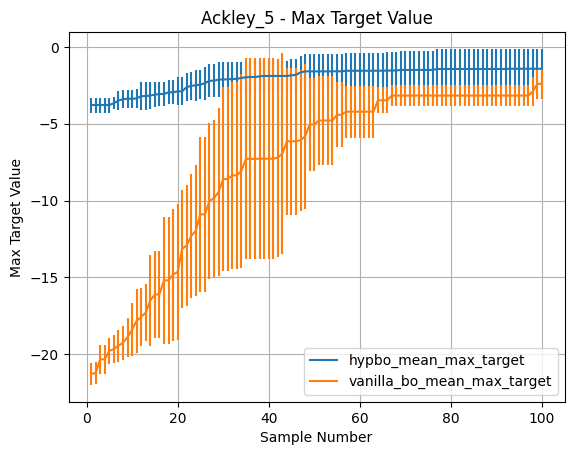

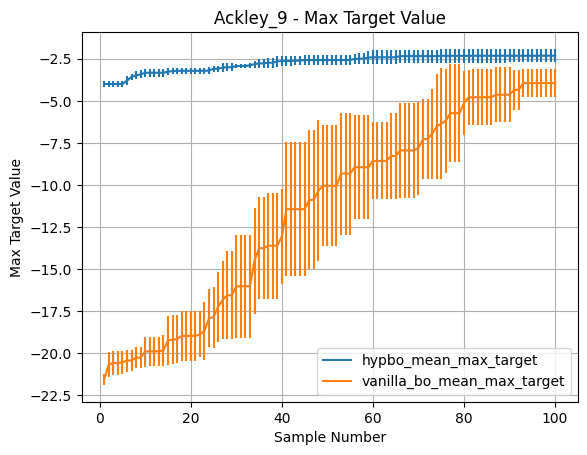

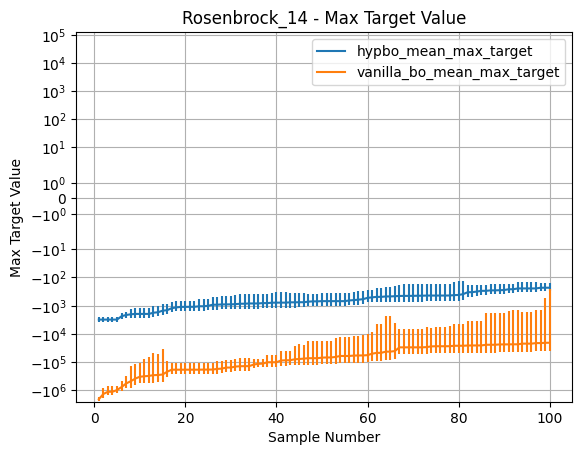

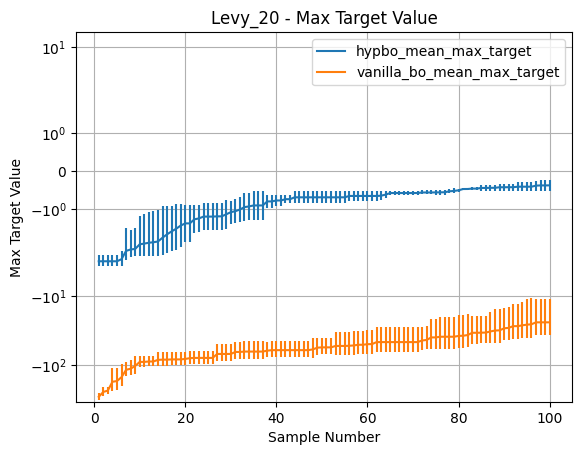

In [ ]:
# %matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np

data_dir = Path("data") / "new_version"
experiments = [("Ackley", 5), ("Ackley", 9), ("Rosenbrock", 14), ("Levy", 20)]
methods = ["hypbo", "vanilla_bo"]

for experiment, dim in experiments:
    method_cons_pairs = []
    exp_df = pd.DataFrame()
    for method in methods:
        exp_dir = data_dir / method / f"{experiment}_{dim}"
        if not exp_dir.exists():
            print(f"Directory {exp_dir} does not exist.")
            continue
        files = list(exp_dir.glob("*.csv"))
        for file in files:
            seed = file.stem.split("_")[-1]
            df = pd.read_csv(file)
            # Ensure correct dtypes
            df["iteration"] = pd.to_numeric(df["iteration"], errors="coerce")
            df["target"] = pd.to_numeric(df["target"], errors="coerce")
            if "iteration" not in exp_df.columns:
                exp_df["iteration"] = df["iteration"]
            exp_df[f"{method}_max_target_{seed}"] = df["target"].cummax()
            exp_df[f"{method}_target_{seed}"] = df["target"]

        if "sample_number" not in exp_df.columns:
            exp_df["sample_number"] = range(1, len(exp_df) + 1)
        exp_df[f"{method}_mean_max_target"] = exp_df.filter(
            like=f"{method}_max_target_"
        ).mean(axis=1)
        exp_df[f"{method}_std_max_target"] = exp_df.filter(
            like=f"{method}_max_target_"
        ).std(axis=1)

    # Plot the mean max target value with error bars over iterations
    errors = np.array(exp_df.filter(like="_std_max_target").values).T
    ax1 = exp_df.plot(
        x="sample_number",
        y=[f"{method}_mean_max_target" for method in methods],
        yerr=errors,
        grid=True,
        legend=True,
        title=f"{experiment}_{dim} - Max Target Value",
        xlabel="Sample Number",
        ylabel="Max Target Value",
    )

    if experiment in ["Levy", "Rosenbrock"]:
        ax1.set_yscale("symlog")